# [실습 10-2] 사전학습 모델 전이학습 — 처음부터 학습 vs 거인의 어깨

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 40~50분 (**GPU 권장**) |
| 본문 연계 | 10.3 전이학습 |
| 선수 실습 | [실습 10-1] (CNN 구조·학습 루프 재사용) |
| 준비 | 부록 B.1·B.3 참고. 최초 실행 시 꽃 데이터(약 220MB)·MobileNetV2 가중치 다운로드 |

꽃 사진 3,700장 — 딥러닝치고는 **아주 적은** 데이터다.
소형 CNN을 처음부터 학습시킨 결과와, 대규모 데이터로
미리 배운 MobileNetV2를 빌려 온 결과를 비교한다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs
# !pip -q install tensorflow-datasets
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch10/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from utils import plot_style, viz

from utils.data import fix_ssl

plot_style.apply()              # 도해 스타일 킷 적용
fix_ssl()                       # 로컬 macOS 다운로드 대비
print("Python", platform.python_version())
print("TensorFlow", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU:", gpus[0].name if gpus else
      "없음 — Colab 메뉴 [런타임 유형 변경]에서 T4 선택")

import warnings
warnings.filterwarnings("ignore")   # Keras 이행기 경고 정리
keras.utils.set_random_seed(7)     # 저장소 재현용 시드
# (지면 안내대로 학습 수치는 초기화·환경에 따라 다소 변동한다)

Python 3.12.6
TensorFlow 2.21.0
GPU: 없음 — Colab 메뉴 [런타임 유형 변경]에서 T4 선택


### [셀 1] 꽃 데이터 준비 📖

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds

(ds_tr, ds_va), info = tfds.load(
    "tf_flowers", as_supervised=True, with_info=True,
    split=["train[:80%]", "train[80%:]"])

def prep(img, label):
    img = tf.image.resize(img, (224, 224)) / 255.0
    return img, label

train = ds_tr.map(prep).batch(32).prefetch(1)
valid = ds_va.map(prep).batch(32).prefetch(1)
print(info.features["label"].names)

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


**핵심 포인트**
- 3,700장 규모 — "수천 장 이하"라는 안전한 시작값의 조건에 정확히 해당하는 현실적 크기다.
- 모든 이미지를 224×224로 통일한다 — 사전학습 모델이 기대하는 입력 크기다.

### [셀 2] Before — 소형 CNN을 밑바닥부터 📖

In [3]:
small = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu",
                  input_shape=(224, 224, 3)),
    layers.MaxPooling2D((4, 4)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((4, 4)),
    layers.Flatten(),
    layers.Dense(5, activation="softmax"),
])
small.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
h1 = small.fit(train, validation_data=valid,
               epochs=10, verbose=0)

I0000 00:00:1784437108.131041 225446665 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


### [셀 3] After — MobileNetV2 동결 + 분류층 교체 📖

In [4]:
base = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False,
    weights="imagenet", pooling="avg")
base.trainable = False        # 특징 추출부 동결

transfer = keras.Sequential([
    base,
    layers.Dense(5, activation="softmax"),  # 새 분류층
])
transfer.compile(
    optimizer="adam",  # 동결 단계는 기본 학습률
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
h2 = transfer.fit(train, validation_data=valid,
                  epochs=10, verbose=0)

**핵심 포인트**
- 본문 〈사전학습과 파인튜닝〉 전략의 핵심은 코드 한 줄, 곧 `base.trainable = False`(동결)다. 새 분류층만 학습하는 동결 단계에는 보호할 사전학습 가중치가 없으므로 학습률은 기본값을 그대로 쓴다. 1/10로 낮추는 규칙은 동결을 푸는 해동(파인튜닝) 단계의 것이다([심화 1]의 자리).
- `weights="imagenet"`이 "이미 길러진 감정사"를 내려받는 부분, `include_top=False`가 원래 분류층을 떼어 내는 부분이다.

### [셀 4] 결과 비교 📖

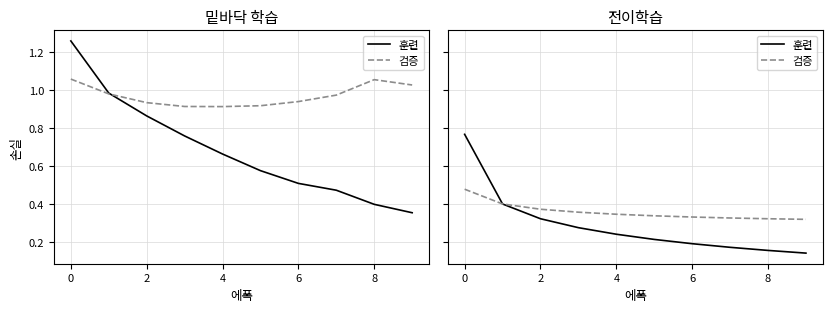

밑바닥 최종: 0.663
전이 최종:   0.905


In [5]:
viz.plot_curves_pair(h1, h2,
                     labels=("밑바닥 학습", "전이학습"))
print(f"밑바닥 최종: {h1.history['val_accuracy'][-1]:.3f}")
print(f"전이 최종:   {h2.history['val_accuracy'][-1]:.3f}")

**핵심 포인트**
- 3,700장 규모에서 격차는 압도적이다. 전이학습은 첫 에폭부터 높은 성적으로 시작한다. 이미 특징을 아는 감정사에게 꽃 이름표만 새로 가르친 셈이다. 밑바닥 곡선은 피크 이후 정체·미세 하락한다. 과적합의 실물이다.
- 저장소 [보조 1]에서 증강 파이프라인을, [심화 1]에서 상위 층 해동 파인튜닝(학습률 1/10 검증)을 실험할 수 있다.

### [보조 1] 데이터 증강 파이프라인 (10.3 연동)

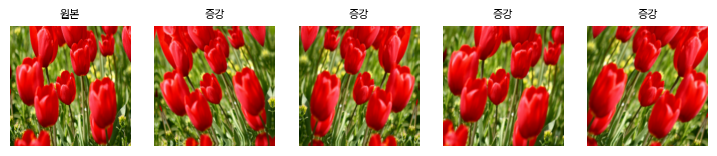

In [6]:
aug = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])
imgs, _ = next(iter(train))
fig, axes = plt.subplots(1, 5, figsize=(9, 2))
axes[0].imshow(imgs[0].numpy())
axes[0].set_title("원본", fontsize=8)
for ax in axes[1:]:
    ax.imshow(aug(imgs[:1])[0].numpy())
    ax.set_title("증강", fontsize=8)
for ax in axes:
    ax.axis("off")
plt.show()
# 한 장이 여러 장이 된다 — 소규모 데이터의 표준 처방

### [심화 1] 미세 조정 — 상위 층 일부 해동 (연습문제 연계)

In [7]:
# TODO: 동결을 일부 풀고(위쪽 30개 층) 학습률을
#       다시 1/10로 낮춰 이어서 학습해 보자.
#       "해동 범위 ↑ = 유연성 ↑ 그러나 과적합 위험 ↑"
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
transfer.compile(
    optimizer=keras.optimizers.Adam(1e-5),  # 또 1/10
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])
# h3 = transfer.fit(train, epochs=3,
#                   validation_data=valid)

---
## 마무리

- 데이터가 적을 때의 정석: **동결 + 분류층 교체(기본 학습률)** — 사실상 `base.trainable = False` 한 줄의 결정이다. 낮은 학습률(1/10)은 그것으로 부족할 때 [심화 1]의 **해동(파인튜닝) 단계**에서 더한다.
- 전이학습은 "이미 배운 표현"의 재사용이다 — 8.5 표현학습 브리지가 여기서 실전이 된다.
- 판단 기준(10.3 표): 데이터 규모와 도메인 유사도가 동결 범위를 정한다 — [심화 1]에서 직접 검증할 수 있다.

**연습문제 연계**: [응용] 시나리오별 전이 전략 선택 문항의 판단 근거가 [셀 4]와 [심화 1] 결과다.

**다음 실습**: [실습 10-3] 확산 모델 체험 — 저장소 전용 (`lab-10-03_diffusion-demo.ipynb`)